# Lab 2 — Logistic Regression (Loan Default)

**Day 03 · Classification & Model Interpretation · Cisco AI/ML Training**

---

## Goals

1. Prepare feature matrix $X$ and binary target $y$ for classification.
2. Split data with **stratification** to preserve class balance.
3. Fit **`LogisticRegression`** and interpret intercept / coefficients.
4. Compare **`predict_proba`** (probability) vs **`predict`** (hard label).

> **Quick check:** train **800** / test **200** · `int_rate` coef positive · sample preds include **0** and **1**




## Logistic regression in one slide

**Linear model on log-odds:**

$$\text{logit}(p) = \ln\frac{p}{1-p} = \beta_0 + \beta_1 x_1 + \cdots + \beta_p x_p$$

**Sigmoid converts back to probability:**

$$p = \frac{1}{1 + e^{-(\beta_0 + \beta_1 x_1 + \cdots)}}$$

| vs Day 2 Linear Regression | Logistic Regression |
|---------------------------|---------------------|
| Target: continuous rating | Target: 0/1 default |
| Output: any real number | Output: probability in [0, 1] |
| `LinearRegression` | `LogisticRegression` |

---

## 1. Load data and select features

In [1]:
%matplotlib inline

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

**Step 2** — run the cell below and read the printed summary. <!-- cisco-split-debug-2026 -->

In [2]:
GH_ROOT = Path.cwd().resolve()
if GH_ROOT.name == "notebooks":
    GH_ROOT = GH_ROOT.parents[2]
elif (GH_ROOT.parent / "notebooks").is_dir() and (GH_ROOT.parents[1] / "requirements-student.txt").is_file():
    GH_ROOT = GH_ROOT.parents[1]
else:
    for parent in [GH_ROOT, *GH_ROOT.parents]:
        if (parent / "requirements-student.txt").is_file():
            GH_ROOT = parent
            break

**Step 3** — run the cell below and read the printed summary. <!-- cisco-split-debug-2026 -->

In [3]:
LENDING_CLUB_CSV = GH_ROOT / "data" / "lending-club" / "lending_club_sample.csv"
DEFAULT_STATUSES = {"Charged Off", "Late (31-120 days)"}
NUMERIC_FEATURES = ["loan_amnt", "int_rate", "annual_inc", "dti", "installment"]
CATEGORICAL_FEATURES = ["grade", "term"]

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

df = pd.read_csv(LENDING_CLUB_CSV)
df["default"] = df["loan_status"].isin(DEFAULT_STATUSES).astype(int)

X = df[NUMERIC_FEATURES]
y = df["default"]

print(f"X shape: {X.shape}")
print(f"default rate: {y.mean():.4f}")
display(X.head(3))

X shape: (1000, 5)
default rate: 0.4850


,loan_amnt,int_rate,annual_inc,dti,installment
0,34498,14.50,35829,15.66,98.07
1,33265,6.75,105184,5.91,859.60
2,4012,6.48,139128,13.90,320.56


### 1b. Feature dtypes and ranges

In [4]:
display(X.describe().round(2))
print("Any missing?", X.isna().any().any())


,loan_amnt,int_rate,annual_inc,dti,installment
count,1000.00,1000.00,1000.00,1000.00,1000.00
mean,18117.78,14.31,103132.76,19.71,463.44
std,9968.01,5.49,45192.41,8.47,244.77
min,1040.00,5.03,25107.00,5.03,51.15
25%,9173.50,9.52,63004.00,12.44,243.05
50%,18290.00,14.35,102884.00,19.30,451.08
75%,26676.25,19.20,141821.50,27.01,682.26
max,34999.00,23.99,179778.00,35.00,899.85


Any missing? False


### 1c. Correlation among numeric features

In [5]:
corr = X.corr().round(3)
display(corr)


,loan_amnt,int_rate,annual_inc,dti,installment
loan_amnt,1.000,0.033,-0.053,0.002,0.009
int_rate,0.033,1.000,-0.008,-0.012,-0.014
annual_inc,-0.053,-0.008,1.000,0.042,-0.012
dti,0.002,-0.012,0.042,1.000,-0.048
installment,0.009,-0.014,-0.012,-0.048,1.000


---

## 2. Train/test split with stratification

`stratify=y` keeps the same default rate in train and test — important when classes are imbalanced (critical on Day 6).

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"train size: {len(X_train)}")
print(f"test size:  {len(X_test)}")
print(f"default rate (train): {y_train.mean():.4f}")
print(f"default rate (test):  {y_test.mean():.4f}")

assert len(X_train) == 800 and len(X_test) == 200


train size: 800
test size:  200
default rate (train): 0.4850
default rate (test):  0.4850


### 2b. Why 80/20 and random_state=42

In [7]:
print("800 train rows → fit coefficients")
print("200 test rows  → honest evaluation in Labs 3–4")
print("random_state=42 → same split every time you re-run")


800 train rows → fit coefficients
200 test rows  → honest evaluation in Labs 3–4
random_state=42 → same split every time you re-run


---

## 3. Fit logistic regression

In [8]:
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

print("Lab 2 — Logistic regression")
print(f"intercept (beta_0): {model.intercept_[0]:.4f}")
for name, coef in zip(NUMERIC_FEATURES, model.coef_[0]):
    print(f"  {name}: {coef:.4f}")


Lab 2 — Logistic regression
intercept (beta_0): -1.4009
  loan_amnt: -0.0000
  int_rate: 0.0795
  annual_inc: -0.0000
  dti: 0.0395
  installment: -0.0006


### Coefficient interpretation

- **`int_rate` (+):** Higher interest rate → higher log-odds of default.
- **`dti` (+):** Higher debt-to-income → higher default log-odds.
- Coefficients are on the **log-odds scale**, not probability directly.

### 3b. Rank features by |coefficient|

In [9]:
coef_df = pd.DataFrame({
    "feature": NUMERIC_FEATURES,
    "coef": model.coef_[0],
    "abs_coef": np.abs(model.coef_[0]),
}).sort_values("abs_coef", ascending=False)
display(coef_df.round(4))


,feature,coef,abs_coef
1,int_rate,0.0795,0.0795
3,dti,0.0395,0.0395
4,installment,-0.0006,0.0006
0,loan_amnt,-0.0000,0.0000
2,annual_inc,-0.0000,0.0000


---

## 4. Sigmoid visualization

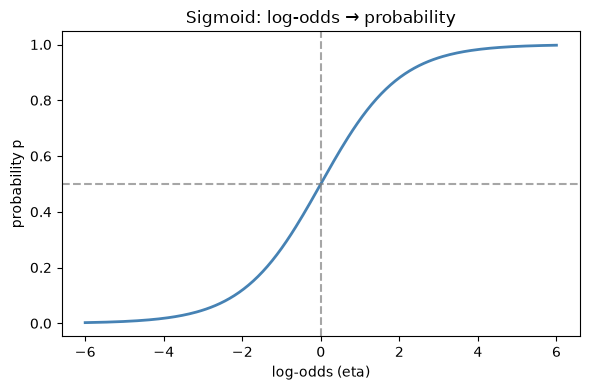

In [10]:
x = np.linspace(-6, 6, 200)
sigmoid = 1 / (1 + np.exp(-x))

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(x, sigmoid, color="steelblue", lw=2)
ax.axhline(0.5, color="gray", linestyle="--", alpha=0.7)
ax.axvline(0, color="gray", linestyle="--", alpha=0.7)
ax.set_xlabel("log-odds (eta)")
ax.set_ylabel("probability p")
ax.set_title("Sigmoid: log-odds → probability")
plt.tight_layout()
plt.show()


At log-odds = 0, probability = **0.5** — the default classification threshold for `predict()`.

---

## 5. `predict_proba` vs `predict`

| Method | Output |
|--------|--------|
| `predict_proba(X)[:, 1]` | P(default=1) per row |
| `predict(X)` | 0 or 1 using threshold **0.5** |

In [11]:
proba = model.predict_proba(X_test.head(3))[:, 1]
pred = model.predict(X_test.head(3))

comparison = pd.DataFrame({
    "int_rate": X_test.head(3)["int_rate"].values,
    "dti": X_test.head(3)["dti"].values,
    "P(default)": proba.round(4),
    "predicted_label": pred,
    "actual_default": y_test.head(3).values,
})
display(comparison)

print(f"sample P(default): {proba.round(4)}")
print(f"sample predictions: {pred.tolist()}")
assert 0 in pred and 1 in pred


,int_rate,dti,P(default),predicted_label,actual_default
0,18.69,26.05,0.6850,1,1
1,8.89,22.20,0.3550,0,0
2,20.72,18.75,0.5472,1,1


sample P(default): [0.685  0.355  0.5472]
sample predictions: [1, 0, 1]


Row with P(default) ≥ **0.5** → predicted **1**. Below 0.5 → predicted **0**.

### 5b. Probability distribution on test set

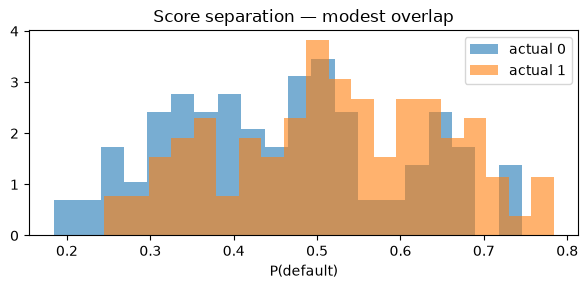

In [12]:
test_proba = model.predict_proba(X_test)[:, 1]
fig, ax = plt.subplots(figsize=(6, 3))
ax.hist(test_proba[y_test == 0], bins=20, alpha=0.6, label="actual 0", density=True)
ax.hist(test_proba[y_test == 1], bins=20, alpha=0.6, label="actual 1", density=True)
ax.set_xlabel("P(default)")
ax.legend()
ax.set_title("Score separation — modest overlap")
plt.tight_layout()
plt.show()


---

## 6. Manual log-odds for one test row

In [13]:
row = X_test.iloc[0]
eta = model.intercept_[0] + np.dot(model.coef_[0], row.values)
p_manual = 1 / (1 + np.exp(-eta))
p_sklearn = model.predict_proba(row.values.reshape(1, -1))[0, 1]

print(f"log-odds eta: {eta:.4f}")
print(f"manual p:     {p_manual:.4f}")
print(f"sklearn p:    {p_sklearn:.4f}")


log-odds eta: 0.7769
manual p:     0.6850
sklearn p:    0.6850


C:\25-Trainings\2-Confirmed\10-June-26-AI-ML-Cisco\GH\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


### 6b. Break down eta by feature

In [14]:
contributions = model.coef_[0] * row.values
contrib_df = pd.DataFrame({
    "feature": NUMERIC_FEATURES,
    "value": row.values,
    "beta*x": contributions,
})
display(contrib_df.round(4))
print(f"intercept + sum(beta*x) = {model.intercept_[0] + contributions.sum():.4f}")


,feature,value,beta*x
0,loan_amnt,9132.00,-0.0864
1,int_rate,18.69,1.4865
2,annual_inc,139591.00,-0.1671
3,dti,26.05,1.0297
4,installment,138.17,-0.0848


intercept + sum(beta*x) = 0.7769


---

## 7. Exploratory plots — features vs default

C:\Users\PC\AppData\Local\Temp\ipykernel_6452\1086049520.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="default", y="int_rate", ax=axes[0], palette="Set2")


C:\Users\PC\AppData\Local\Temp\ipykernel_6452\1086049520.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="default", y="dti", ax=axes[1], palette="Set2")


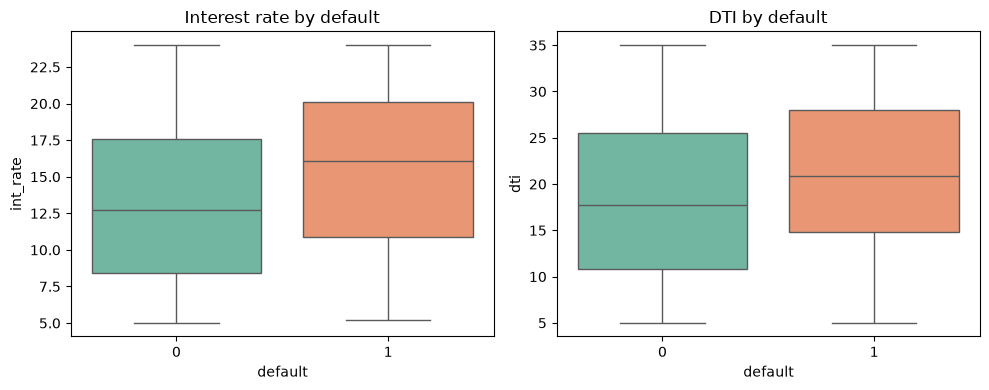

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.boxplot(data=df, x="default", y="int_rate", ax=axes[0], palette="Set2")
axes[0].set_title("Interest rate by default")
sns.boxplot(data=df, x="default", y="dti", ax=axes[1], palette="Set2")
axes[1].set_title("DTI by default")
plt.tight_layout()
plt.show()


Defaults tend toward higher `int_rate` and `dti` — consistent with positive coefficients.

### 7b. Annual income and loan amount

C:\Users\PC\AppData\Local\Temp\ipykernel_6452\1551234562.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="default", y="annual_inc", ax=axes[0], palette="Set2")
C:\Users\PC\AppData\Local\Temp\ipykernel_6452\1551234562.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="default", y="loan_amnt", ax=axes[1], palette="Set2")


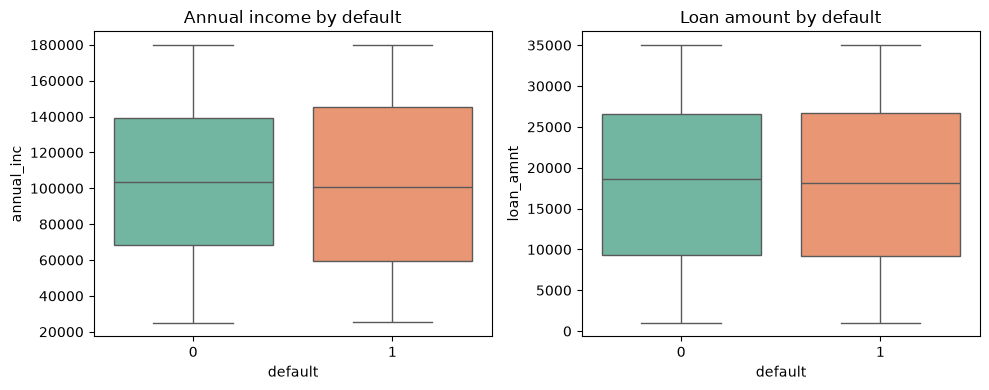

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.boxplot(data=df, x="default", y="annual_inc", ax=axes[0], palette="Set2")
axes[0].set_title("Annual income by default")
sns.boxplot(data=df, x="default", y="loan_amnt", ax=axes[1], palette="Set2")
axes[1].set_title("Loan amount by default")
plt.tight_layout()
plt.show()


---

## 8. Training accuracy (not the final metric)

In [17]:
from sklearn.metrics import accuracy_score

train_acc = accuracy_score(y_train, model.predict(X_train))
test_acc = accuracy_score(y_test, model.predict(X_test))
print(f"train accuracy: {train_acc:.4f}")
print(f"test accuracy:  {test_acc:.4f}")
print("(Lab 3 adds confusion matrix, precision, recall, F1)")


train accuracy: 0.6112
test accuracy:  0.5900
(Lab 3 adds confusion matrix, precision, recall, F1)


### 8b. Overfitting check

In [18]:
gap = train_acc - test_acc
print(f"train - test gap: {gap:.4f}")
print("Small gap here — model is simple; still evaluate on held-out test.")


train - test gap: 0.0212
Small gap here — model is simple; still evaluate on held-out test.


### 8c. Default rate by predicted probability bucket

In [19]:
buckets = pd.cut(test_proba, bins=[0, 0.3, 0.5, 0.7, 1.0])
cal = pd.DataFrame({"bucket": buckets, "actual": y_test.values}).groupby("bucket")["actual"].mean()
print("Empirical default rate by score bucket:")
print(cal.round(3))


Empirical default rate by score bucket:
bucket
(0.0, 0.3]    0.250
(0.3, 0.5]    0.427
(0.5, 0.7]    0.566
(0.7, 1.0]    0.667
Name: actual, dtype: float64


C:\Users\PC\AppData\Local\Temp\ipykernel_6452\2989034106.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cal = pd.DataFrame({"bucket": buckets, "actual": y_test.values}).groupby("bucket")["actual"].mean()


---

## 8d. Standardize features (preview of Lab 6)

In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

model_s = LogisticRegression(max_iter=1000, random_state=42)
model_s.fit(X_train_s, y_train)
print("Scaled model test accuracy:", round(accuracy_score(y_test, model_s.predict(X_test_s)), 4))
print("(Coefficients change scale; predictions at 0.5 threshold stay similar.)")


Scaled model test accuracy: 0.59
(Coefficients change scale; predictions at 0.5 threshold stay similar.)


### 8e. Installment vs default

C:\Users\PC\AppData\Local\Temp\ipykernel_6452\1642863325.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="default", y="installment", ax=ax, palette="Set2")


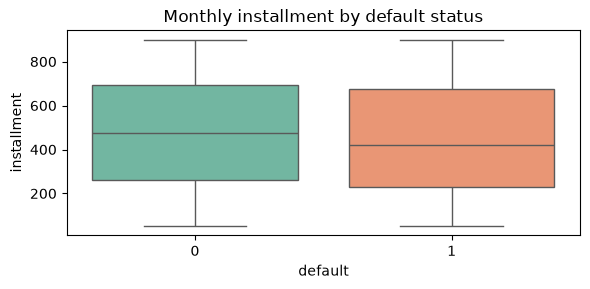

In [21]:
fig, ax = plt.subplots(figsize=(6, 3))
sns.boxplot(data=df, x="default", y="installment", ax=ax, palette="Set2")
ax.set_title("Monthly installment by default status")
plt.tight_layout()
plt.show()


### 8f. Grade distribution in training set

In [22]:
print(df.loc[X_train.index, "grade"].value_counts().sort_index())


# cisco-debug-summary
print("Value counts — long tail categories may be omitted.")

grade
A    123
B    111
C    121
D     96
E    109
F    114
G    126
Name: count, dtype: int64
Value counts — long tail categories may be omitted.


### 8g. Predict on a synthetic high-risk profile

In [23]:
high_risk = pd.DataFrame([{
    "loan_amnt": 25000, "int_rate": 18.0, "annual_inc": 45000,
    "dti": 28.0, "installment": 850,
}])
p_hr = model.predict_proba(high_risk)[0, 1]
print(f"P(default) high-risk profile: {p_hr:.4f}")


P(default) high-risk profile: 0.5806


### 8h. Predict on a synthetic low-risk profile

In [24]:
low_risk = pd.DataFrame([{
    "loan_amnt": 10000, "int_rate": 7.5, "annual_inc": 95000,
    "dti": 8.0, "installment": 310,
}])
p_lr = model.predict_proba(low_risk)[0, 1]
print(f"P(default) low-risk profile: {p_lr:.4f}")


P(default) low-risk profile: 0.2918


---

## 9. Try it yourself

Pick one test row. Compute log-odds manually and compare to `predict_proba`.

In [25]:
# Your code here


In [26]:
row2 = X_test.iloc[5]
eta2 = model.intercept_[0] + np.dot(model.coef_[0], row2.values)
p2 = 1 / (1 + np.exp(-eta2))
print(f"manual P(default): {p2:.4f}")
print(f"sklearn:           {model.predict_proba(row2.values.reshape(1,-1))[0,1]:.4f}")


manual P(default): 0.3485
sklearn:           0.3485


C:\25-Trainings\2-Confirmed\10-June-26-AI-ML-Cisco\GH\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


---

## 10. Checkpoint summary

In [27]:
print("=" * 50)
print(f"train: {len(X_train)}, test: {len(X_test)}")
print(f"intercept: {model.intercept_[0]:.4f}")
print(f"int_rate coef: {model.coef_[0][1]:.4f} (expect > 0)")
assert model.coef_[0][1] > 0
assert model.coef_[0][3] > 0  # dti
print("\n✓ Checkpoint assertions passed")


train: 800, test: 200
intercept: -1.4009
int_rate coef: 0.0795 (expect > 0)

✓ Checkpoint assertions passed


---

## Reflection questions

1. What happens to predictions if you change the threshold from 0.5 to 0.7?
2. Why use `stratify=y` even when classes are nearly balanced?
3. Which metrics evaluate this model best? *(Lab 3 — confusion matrix, Lab 4 — AUC)*
4. Why are coefficients on log-odds, not probability?
